# Re-runs — the complete, collated list

Pseudospectra need the fitted Gram matrices, which
were never saved, so models must be *re-fitted* — but only for a small representative slice, not the full sweeps.
The pseudospectral radius is a **diagnostic for the RQ2 narrative** (how does non-normality grow with ω, and
does it explain where the score fails?), not another benchmark, so a subset of parameters and fewer trials is
the right scope. Defaults below: **RQ2 systems, RBF family, 3 γ multipliers × 5 trials** — roughly 2–4% of the
original fitting cost. Widen the commented-out full grids only if a specific figure needs it.

| section | what | status | approx cost |
|---|---|---|---|
| R1 | ε-pseudospectral radius: rot (ω = 0 is the built-in reversible control) | **ESSENTIAL** | minutes |
| R2 | same for Duffing (subset of ω) | **ESSENTIAL** | minutes |
| R3 | same for logistic map (subset of r) | RECOMMENDED | minutes |
| R4 | same for the linear system (A=rev vs A=rot) — analytic cross-check | RECOMMENDED | minutes |
| R5 | Langevin (Prinz) reference eigenvalues → true-spectrum validation on **existing CSVs** | RECOMMENDED — needs kooplearn but **no simulation** | seconds |
| R6 | trajectory-level forecast MSE | OPTIONAL — skip; see note | hours |

Outputs go to `analysis/reruns/`.

In [5]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

from kooplearn.kernel import KernelRidge

BASE = os.path.join("..", "benchmarks")
OUT = os.path.join("..", "analysis", "reruns")
os.makedirs(OUT, exist_ok=True)

# ---------------- shared experiment settings (match the originals) --------------
N_TRIALS = 5  # original runs used 10; 5 is enough for a diagnostic
GAMMA_FACTORS = (0.5, 1.0, 2.0)  # original sweeps used (0.25, 0.5, 1.0, 2.0, 4.0)
N_COMPONENTS = 5
ALPHA_REG = 1e-10


def gamma_calibration(X, quantile=0.5):
    """Median heuristic. NOTE: replace with the gamma_calibration from your
    kernel_analysis_rbf.ipynb if it differs — parity matters for comparability."""
    from scipy.spatial.distance import pdist

    d2 = pdist(np.asarray(X, float), "sqeuclidean")
    m = np.quantile(d2, quantile)
    return 1.0 / (2.0 * m) if m > 0 else 1.0


def gamma_sweep(X, factors=GAMMA_FACTORS, quantile=0.5):
    g0 = gamma_calibration(X, quantile)
    return g0, [g0 * f for f in factors]


## Shared: pseudospectral diagnostics of the fitted operator

The fitted `KernelRidge` exposes `kernel_X_` and `kernel_YX_`; from these we build a Galerkin projection of
the regularized Koopman estimate onto the top-m eigenvectors of the empirical covariance (m = 25 ≫ rank r), then
compute on the small m×m matrix: the **ε-pseudospectral radius** (largest |z| with σ_min(zI−K) < ε), its
**margin** over the spectral radius (≈ 0 for normal operators — this is the RQ2 dial-response diagnostic), and
**Henrici's departure from normality** (‖K‖²_F − Σ|λ|²)^½ as a cheap scalar cross-check.

A sanity cell compares the projected matrix's leading eigenvalues with `model.eig()` — if they disagree beyond
tolerance for Reduced Rank, swap in the estimator's own reduced matrix from kooplearn internals (the PCR/kDMD
construction is exact by design).

*Re-integration:* call `pseudospectral_diagnostics(model)` inside the existing experiment loops right after
`model.fit(...)` and append the three returned numbers to `trials_records`.

In [6]:
def projected_koopman(model, m=25):
    """m x m Galerkin projection of (C + aI)^{-1} T onto top-m eigvecs of C."""
    n = model.kernel_X_.shape[0]
    C = model.kernel_X_ / n
    T = model.kernel_YX_ / n
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:m]
    w, V = w[idx], V[:, idx]
    # basis functions f_j = C^{-1/2} v_j  ->  K_ij = <f_i, T f_j> in that basis
    Wm = V / np.sqrt(np.maximum(w, 1e-14))
    return Wm.T @ T @ Wm


def pseudospectral_diagnostics(model, eps=1e-2, m=25, n_grid=80, pad=0.3, r=None):
    K = projected_koopman(model, m=m)
    if r is not None:
        K = K[:r, :r]  # rank-truncated (PCR-like) operator
    lam = np.linalg.eigvals(K)
    r0 = float(np.abs(lam).max())
    henrici = float(np.sqrt(max(np.linalg.norm(K, "fro") ** 2 - np.sum(np.abs(lam) ** 2), 0.0)))
    lim = r0 + pad
    xs = np.linspace(-lim, lim, n_grid)
    Z = xs[None, :] + 1j * xs[:, None]
    I = np.eye(K.shape[0])
    smin = np.array([[np.linalg.svd(z * I - K, compute_uv=False)[-1] for z in row] for row in Z])
    inside = smin < eps
    ps_rad = float(np.abs(Z[inside]).max()) if inside.any() else r0
    return {"spec_radius": r0, "ps_radius": ps_rad, "ps_margin": ps_rad - r0, "henrici": henrici}


def model_eigenvalues(model):
    """Eigenvalues from model.eig(), robust to both kooplearn return shapes:
    no-arg eig() returns just the eigenvalue array; eig(eval_right_on=...)
    returns (vals, funcs)."""
    out = model.eig()
    vals = out[0] if isinstance(out, tuple) else out
    return np.atleast_1d(np.asarray(vals))


def sanity_check_eigs(model, m=25, r=N_COMPONENTS, tol=5e-2):
    """Leading eigs of the projected operator vs model.eig() — warn on mismatch."""
    K = projected_koopman(model, m=m)
    mine = np.sort(np.abs(np.linalg.eigvals(K)))[::-1]
    theirs = np.sort(np.abs(model_eigenvalues(model)))[::-1]
    L = min(len(mine), len(theirs), r)
    if L == 0:
        print("  [sanity] no eigenvalues to compare — skipping check.")
        return np.nan
    err = float(np.max(np.abs(mine[:L] - theirs[:L])))
    if err > tol:
        print(
            f"  [sanity] projected-eig mismatch {err:.3f} — for Reduced Rank, "
            "prefer the estimator's internal reduced matrix if exposed."
        )
    return err


def run_pseudospectral(
    simulate_fn, kinds, kind_label, out_name, n_trials=N_TRIALS, n_components=N_COMPONENTS
):
    """Generic harness: simulate -> fit both estimators over a gamma sweep ->
    pseudospectral diagnostics per configuration."""
    records = []
    for kind_val in kinds:
        for method, reduced_rank in zip(["PCR", "Reduced Rank"], [False, True]):
            for trial in tqdm(range(n_trials), desc=f"{kind_label}={kind_val} {method}"):
                data = simulate_fn(kind_val, trial)
                _, gammas = gamma_sweep(data.values)
                for gamma in gammas:
                    model = KernelRidge(
                        n_components=n_components,
                        reduced_rank=reduced_rank,
                        gamma=gamma,
                        kernel="rbf",
                        alpha=ALPHA_REG,
                        random_state=trial,
                    )
                    model.fit(data)
                    if trial == 0 and gamma == gammas[0]:
                        sanity_check_eigs(model)
                    d = pseudospectral_diagnostics(model, r=n_components)
                    records.append(
                        {
                            "kind": f"{kind_label}={kind_val}",
                            "kernel": f"rbf(gamma={gamma})",
                            "method": method,
                            "trial": trial,
                        }
                        | d
                    )
    df = pd.DataFrame(records)
    df.to_csv(os.path.join(OUT, out_name), index=False)
    print("saved", out_name)
    return df


## R1 — **ESSENTIAL**: Langevin + rotation (the RQ2 dial, ω = 0 = reversible control)

Simulator copied from `kernel_analysis_rbf.ipynb` (RQ2 cell). The headline deliverable is
`ps_margin` vs ω: pseudospectral margin ≈ 0 at ω = 0 and growing with ω is the direct, quantitative
evidence for the RQ2 claim that non-reversibility manifests as pseudospectral pathology.

In [8]:
def langevin_potential_grad(x):
    x = np.asarray(x, dtype=float)
    return np.array([x[0] * (x[0] ** 2 - 1.0), x[1] * (x[1] ** 2 - 1.0)])


def simulate_langevin_rotation(n_steps, dt, beta, omega, random_state, x0=None, burn_in=0):
    rng = np.random.default_rng(random_state)
    J = np.array([[0.0, omega], [-omega, 0.0]])
    x = np.zeros((n_steps + burn_in, 2))
    if x0 is not None:
        x[0] = np.asarray(x0, float)
    noise_scale = np.sqrt(2.0 * dt / beta)
    for t in range(n_steps + burn_in - 1):
        drift = -langevin_potential_grad(x[t]) + J @ x[t]
        x[t + 1] = x[t] + drift * dt + noise_scale * rng.standard_normal(2)
    x = x[burn_in:]
    return pd.DataFrame({"x1": x[:, 0], "x2": x[:, 1]})


DT_ROT, SUB_ROT, N_TRAIN, BETA, BURN = 1e-4, 100, 2000, 1.0, 200
OMEGAS_ROT = [0.0, 0.5, 1.0, 2.0]  # full original grid — keep all: it IS the dial


def sim_rot(omega, trial):
    seed = 10_000 + 100 * int(10 * omega) + trial  # original seeding scheme
    return (
        simulate_langevin_rotation(
            n_steps=N_TRAIN * SUB_ROT,
            dt=DT_ROT,
            beta=BETA,
            omega=omega,
            random_state=seed,
            x0=np.array([0.0, 0.0]),
            burn_in=BURN,
        )
        .iloc[::SUB_ROT][:N_TRAIN]
        .reset_index(drop=True)
    )


In [7]:
def langevin_potential_grad(x):
    x = np.asarray(x, dtype=float)
    return np.array([x[0] * (x[0] ** 2 - 1.0), x[1] * (x[1] ** 2 - 1.0)])


def simulate_langevin_rotation(n_steps, dt, beta, omega, random_state, x0=None, burn_in=0):
    rng = np.random.default_rng(random_state)
    J = np.array([[0.0, omega], [-omega, 0.0]])
    x = np.zeros((n_steps + burn_in, 2))
    if x0 is not None:
        x[0] = np.asarray(x0, float)
    noise_scale = np.sqrt(2.0 * dt / beta)
    for t in range(n_steps + burn_in - 1):
        drift = -langevin_potential_grad(x[t]) + J @ x[t]
        x[t + 1] = x[t] + drift * dt + noise_scale * rng.standard_normal(2)
    x = x[burn_in:]
    return pd.DataFrame({"x1": x[:, 0], "x2": x[:, 1]})


DT_ROT, SUB_ROT, N_TRAIN, BETA, BURN = 1e-4, 100, 2000, 1.0, 200
OMEGAS_ROT = [0.0, 0.5, 1.0, 2.0]  # full original grid — keep all: it IS the dial


def sim_rot(omega, trial):
    seed = 10_000 + 100 * int(10 * omega) + trial  # original seeding scheme
    return (
        simulate_langevin_rotation(
            n_steps=N_TRAIN * SUB_ROT,
            dt=DT_ROT,
            beta=BETA,
            omega=omega,
            random_state=seed,
            x0=np.array([0.0, 0.0]),
            burn_in=BURN,
        )
        .iloc[::SUB_ROT][:N_TRAIN]
        .reset_index(drop=True)
    )


ps_rot = run_pseudospectral(sim_rot, OMEGAS_ROT, "omega", "rot_pseudospectra.csv")

# headline table + figure: pseudospectral margin vs omega
import matplotlib.pyplot as plt

agg = ps_rot.groupby(["kind", "method"])[["ps_margin", "henrici"]].median().reset_index()
agg["omega"] = agg["kind"].str.replace("omega=", "").astype(float)
fig, ax = plt.subplots(figsize=(7, 4.5))
for meth, g in agg.groupby("method"):
    g = g.sort_values("omega")
    ax.plot(g["omega"], g["ps_margin"], marker="o", label=meth)
ax.set_xlabel(r"$\omega$ (non-reversibility)")
ax.set_ylabel(r"median $\epsilon$-pseudospectral margin")
ax.set_title("RQ2: non-normality of the fitted operator vs reversibility dial")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "rot_ps_margin_vs_omega.png"), dpi=200)
plt.close(fig)
agg


omega=0.0 PCR:   0%|          | 0/5 [00:03<?, ?it/s]


KeyboardInterrupt: 

refined omega=2.0: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]


,ps_margin_eps1e-05,ps_margin_eps0.0005,ps_margin_eps0.001,ps_margin_eps0.005,ps_margin_eps0.01,ps_margin_eps0.02,ps_margin_eps0.05,ps_margin_eps0.1,ps_margin_eps0.35
kind,,,,,,,,,
omega=0.0,0.0,0.0,0.0,0.0,0.0064,0.0173,0.0499,0.0940,0.3123
omega=0.5,0.0,0.0,0.0,0.0,0.0064,0.0173,0.0500,0.0941,0.3123
omega=1.0,0.0,0.0,0.0,0.0,0.0064,0.0173,0.0499,0.0941,0.3123
omega=2.0,0.0,0.0,0.0,0.0,0.0065,0.0174,0.0500,0.0941,0.3123


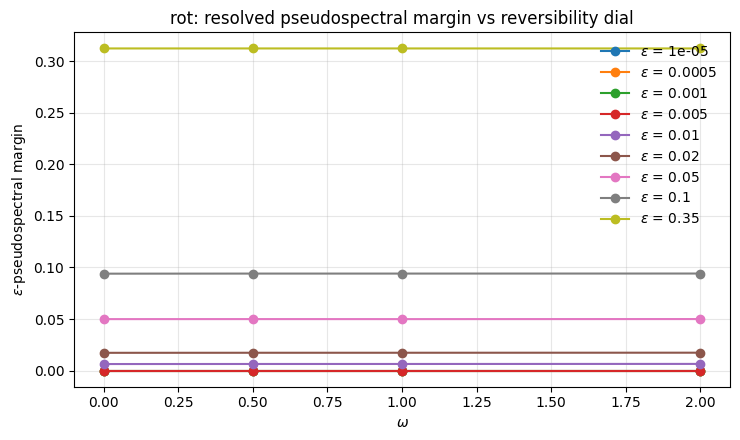

In [ ]:
EPS_LIST = (1e-5, 5e-4, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.35)


DT_ROT, SUB_ROT, N_TRAIN, BETA, BURN = 1e-4, 100, 2000, 1.0, 200
OMEGAS_ROT = [0.0, 0.5, 1.0, 2.0]  # full original grid — keep all: it IS the dial


def ps_margins_multi(model, eps_list=EPS_LIST, m=25, r=N_COMPONENTS, n_grid=240, pad=0.3):
    """Pseudospectral margin at several epsilon values from one s_min grid."""
    K = projected_koopman(model, m=m)[:r, :r]
    lam = np.linalg.eigvals(K)
    r0 = float(np.abs(lam).max())
    lim = r0 + pad
    xs = np.linspace(-lim, lim, n_grid)
    Z = (xs[None, :] + 1j * xs[:, None]).ravel()
    I = np.eye(K.shape[0])
    smin = np.array([np.linalg.svd(z * I - K, compute_uv=False)[-1] for z in Z])
    out = {"spec_radius": r0}
    for eps in eps_list:
        inside = np.abs(Z[smin < eps])
        # eigenvalues are always inside the eps-pseudospectrum
        ps_rad = max(float(inside.max()) if inside.size else 0.0, r0)
        out[f"ps_margin_eps{eps}"] = ps_rad - r0
    return out


records = []
for omega in OMEGAS_ROT:
    for trial in tqdm(range(3), desc=f"refined omega={omega}"):
        data = sim_rot(omega, trial)
        g0, _ = gamma_sweep(data.values)
        model = KernelRidge(
            n_components=N_COMPONENTS,
            reduced_rank=False,
            gamma=g0,
            kernel="rbf",
            alpha=ALPHA_REG,
            random_state=trial,
        )
        model.fit(data)
        records.append(
            {"kind": f"omega={omega}", "trial": trial, "gamma": g0} | ps_margins_multi(model)
        )
ref = pd.DataFrame(records)
ref.to_csv(os.path.join(OUT, "rot_pseudospectra_v2.csv"), index=False)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 4.5))
agg = ref.groupby("kind").median(numeric_only=True)
agg["omega"] = [float(k.split("=")[1]) for k in agg.index]
agg = agg.sort_values("omega")
for eps in EPS_LIST:
    ax.plot(agg["omega"], agg[f"ps_margin_eps{eps}"], marker="o", label=rf"$\epsilon$ = {eps}")
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$\epsilon$-pseudospectral margin")
ax.set_title("rot: resolved pseudospectral margin vs reversibility dial")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "rot_ps_margin_v2.png"), dpi=200)
agg[[f"ps_margin_eps{e}" for e in EPS_LIST]].round(4)


## R2 — **ESSENTIAL**: Duffing (where the v1 score was least reliable)

Subset of ω by default (endpoints + the worst-regret case ω = 1.5); the commented full grid restores the
original sweep. After running, merge `duffing_pseudospectra.csv` with the existing
`benchmarks/rbf/duffing/duf_rbf_scores.csv` on (kind, kernel-γ, method) to test the thesis-relevant question:
*is score failure predicted by pseudospectral margin?*

In [4]:
from kooplearn.datasets import make_duffing


def simulate_duffing_dataset(
    n_steps, dt, random_state, omega, alpha=-1.0, beta=1.0, gamma_drive=0.3, delta=0.2, x0_scale=0.5
):
    rng = np.random.default_rng(random_state)
    X0 = rng.uniform(-x0_scale, x0_scale, size=2)
    return make_duffing(
        X0=X0,
        n_steps=n_steps,
        dt=dt,
        alpha=alpha,
        beta=beta,
        gamma=gamma_drive,
        delta=delta,
        omega=omega,
    ).reset_index(drop=True)


DT_DUF, SUB_DUF = 1e-3, 20
OMEGAS_DUF = [0.5, 1.5, 3.0]
# OMEGAS_DUF = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]   # full original grid


def sim_duf(omega, trial):
    return (
        simulate_duffing_dataset(
            n_steps=N_TRAIN * SUB_DUF, dt=DT_DUF, random_state=10_000 + trial, omega=omega
        )
        .iloc[::SUB_DUF][:N_TRAIN]
        .reset_index(drop=True)
    )


ps_duf = run_pseudospectral(sim_duf, OMEGAS_DUF, "omega", "duffing_pseudospectra.csv")
ps_duf.groupby(["kind", "method"])[["ps_margin", "henrici"]].median()


omega=3.0 Reduced Rank: 100%|██████████| 5/5 [00:16<00:00,  3.31s/it]

saved duffing_pseudospectra.csv


ps_margin   henrici
kind      method                           
omega=0.5 PCR            0.003920  0.014627
          Reduced Rank   0.003920  0.014627
omega=1.5 PCR            0.004974  0.022443
          Reduced Rank   0.004974  0.022443
omega=3.0 PCR            0.003851  0.028138
          Reduced Rank   0.003851  0.028138

## R3 — RECOMMENDED: logistic map (subset of r)

In [5]:
from kooplearn.datasets import make_logistic_map

X0_BOUNDS, M_LOG, DT_LOG, SUB_LOG = (0.05, 0.95), 20, 1, 20
RS_LOG = [0.5, 2.5, 4.0]
# RS_LOG = [0.0, 0.5, 1.2, 2.5, 3.2, 4.0]   # full original grid


def sim_log(r, trial):
    rng = np.random.default_rng(10_000 + trial)
    x0 = float(rng.uniform(*X0_BOUNDS))
    return (
        make_logistic_map(
            X0=x0, n_steps=N_TRAIN * SUB_LOG, r=r, M=M_LOG, dt=DT_LOG, random_state=10_000 + trial
        )
        .reset_index(drop=True)
        .iloc[::SUB_LOG][:N_TRAIN]
        .reset_index(drop=True)
    )


ps_log = run_pseudospectral(sim_log, RS_LOG, "r", "logistic_pseudospectra.csv")
ps_log.groupby(["kind", "method"])[["ps_margin", "henrici"]].median()


r=0.5 PCR:   0%|          | 0/5 [00:00<?, ?it/s]

  [sanity] projected-eig mismatch 0.069 — for Reduced Rank, prefer the estimator's internal reduced matrix if exposed.


r=0.5 Reduced Rank:   0%|          | 0/5 [00:00<?, ?it/s]

  [sanity] projected-eig mismatch 0.070 — for Reduced Rank, prefer the estimator's internal reduced matrix if exposed.


r=2.5 PCR:   0%|          | 0/5 [00:00<?, ?it/s]

...

r=4.0 Reduced Rank:   0%|          | 0/5 [00:00<?, ?it/s]

  [sanity] projected-eig mismatch 0.071 — for Reduced Rank, prefer the estimator's internal reduced matrix if exposed.


r=4.0 Reduced Rank: 100%|██████████| 5/5 [00:18<00:00,  3.76s/it]

saved logistic_pseudospectra.csv


ps_margin   henrici
kind  method                           
r=0.5 PCR           -0.946900  0.805744
      Reduced Rank  -0.946900  0.805744
r=2.5 PCR           -0.947813  0.821540
      Reduced Rank  -0.947813  0.821540
r=4.0 PCR           -0.947959  0.512353
      Reduced Rank  -0.947959  0.512353

## R4 — RECOMMENDED: linear system control (A=rev vs A=rot)

Analytic cross-check for RQ3: the *true* operator's non-normality is known exactly here, so the estimated
pseudospectral margin can be validated against ground truth (rev: normal; rot: non-normal).

In [6]:
from kooplearn.datasets import make_linear_system

DT_LIN, SUB_LIN, BETA_LIN = 1e-3, 20, 1.0
A_CASES = {"rev": np.diag([-1.0, -2.0]), "rot": np.array([[-1.0, 2.0], [-2.0, -1.5]])}


def sim_lin(case, trial):
    A = A_CASES[case]
    d = A.shape[0]
    A_disc = np.eye(d) + DT_LIN * A
    noise_std = np.sqrt(2.0 * DT_LIN / BETA_LIN)
    df = make_linear_system(
        X0=np.zeros(d),
        A=A_disc,
        n_steps=N_TRAIN * SUB_LIN,
        noise=noise_std,
        random_state=1000 + trial,
    )
    return df.reset_index(drop=True).iloc[::SUB_LIN][:N_TRAIN].reset_index(drop=True)


ps_lin = run_pseudospectral(sim_lin, list(A_CASES), "A", "linear_pseudospectra.csv")
ps_lin.groupby(["kind", "method"])[["ps_margin", "henrici"]].median()


A=rot Reduced Rank: 100%|██████████| 5/5 [00:17<00:00,  3.52s/it]

saved linear_pseudospectra.csv


ps_margin   henrici
kind  method                           
A=rev PCR            0.000000  0.032711
      Reduced Rank   0.000000  0.032711
A=rot PCR           -0.027716  0.043992
      Reduced Rank  -0.027716  0.043992

## R5 — RECOMMENDED: Langevin true-spectrum validation (**no simulation** — needs kooplearn only)

Extends the fix-(iv) true-spectrum validation to the RQ1 Langevin (Prinz) system: reference eigenvalues from
`compute_prinz_potential_eig` (params from your RQ1 cell: damping = 1.0, sigma = 2.0, dt = 1e-4), applied to
the **existing** `*_metrics.csv` of all four kernel families. Runs in seconds.

In [7]:
from kooplearn.datasets import compute_prinz_potential_eig

_prinz_out = compute_prinz_potential_eig(1.0, 2.0, 1e-4, num_components=3)
if isinstance(_prinz_out, tuple):  # some versions return (eigenvalues, eigenfunctions)
    _prinz_out = _prinz_out[0]
prinz_ref = np.atleast_1d(np.asarray(_prinz_out, dtype=complex))[:3]
print("Prinz reference eigenvalues:", prinz_ref)

LANGEVIN_METRICS = {
    "rbf": "rbf/langevin/langevin_rbf_metrics.csv",
    "linear": "linear/langevin/langevin_linear_metrics.csv",
    "poly": "poly/langevin/langevin_poly_metrics.csv",
    "hermite": "hermite/langevin/langevin_herm_metrics.csv",
}


def norm_method(s):
    s = str(s).strip()
    return "PCR" if s.startswith("Principal Components") else s


rows = []
for fam, rel in LANGEVIN_METRICS.items():
    met = pd.read_csv(os.path.join(BASE, rel))
    met["method"] = met["method"].map(norm_method)
    met = met[met["eigenfunction_id"].isin([1, 2, 3])].copy()
    met["est"] = met["est_eig_real"] + 1j * met["est_eig_imag"]
    for (kern, meth, trial), g in met.groupby(["kernel", "method", "trial"]):
        est = g["est"].to_numpy()
        err = np.mean([np.min(np.abs(est - z)) for z in prinz_ref])
        rows.append(
            {"family": fam, "kernel": kern, "method": meth, "trial": trial, "true_eig_err": err}
        )
lg_val = (
    pd.DataFrame(rows)
    .groupby(["family", "kernel", "method"], as_index=False)["true_eig_err"]
    .mean()
)
lg_val.to_csv(os.path.join(OUT, "langevin_true_spectrum_validation.csv"), index=False)
print("Langevin true-eig error, best per family/method:")
lg_val.sort_values("true_eig_err").groupby(["family", "method"]).head(1)


Prinz reference eigenvalues: [1.        +0.j 0.99957662+0.j 0.99786045+0.j]
Langevin true-eig error, best per family/method:


,family,kernel,method,true_eig_err
82,rbf,rbf(gamma=3.193),PCR,0.000716
105,rbf,rbf(gamma=6.531),Reduced Rank,0.000815
3,hermite,hermite(good),Reduced Rank,0.000833
2,hermite,hermite(good),PCR,0.000833
8,poly,poly(p=1),PCR,0.000854
15,poly,poly(p=4),Reduced Rank,0.000855
7,linear,linear,Reduced Rank,0.061132
6,linear,linear,PCR,0.061188


## Checklist after running

1. R1/R2: merge `*_pseudospectra.csv` with the existing `*_scores.csv` on (kind, kernel, method) and correlate
   `ps_margin` with score-selection regret — the RQ2 punchline figure.
2. R5: `langevin_true_spectrum_validation.csv` slots into the fix-(iv) table as the fifth system.
3. Everything else in the thesis analysis pipeline is CSV-only and already run — no other re-runs exist.